<a href="https://colab.research.google.com/github/duashah2005/ML_lab/blob/main/SyedaDuaShah_lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Syeda Dua Shah

cms-id: 023-24-0081

section: D

github profile:

In [ ]:
#part 1
#task 1
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('clean_churn_raw.csv')
y = df['Churn'].map({'Yes': 1, 'No': 0}) if df['Churn'].dtype == object else df['Churn']
X = df.drop(columns=['Churn', 'customerID'], errors='ignore')
cat_cols = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

#task 2
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

dt_baseline = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

# Train
dt_baseline.fit(X_train, y_train)

# Predict
y_pred_dt = dt_baseline.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Baseline Results")
print("--------------------------------")
print(f"Accuracy :  {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall   :  {recall:.4f}")
print(f"F1-score :  {f1:.4f}")




X shape: (7043, 6559)
X_train shape: (5634, 6559)
X_test shape: (1409, 6559)
y_train shape: (5634,)
y_test shape: (1409,)
Decision Tree Baseline Results
--------------------------------
Accuracy :  0.7984
Precision:  0.6630
Recall   :  0.4893
F1-score :  0.5631


The Decision Tree with max_depth = 6 is used as the baseline benchmark for Lab 4. It achieved an accuracy of 0.7984, precision of 0.6630, recall of 0.4893, and F1-score of 0.5631 on the test set. These results match the chosen-depth model from Lab 3, confirming that the same preprocessing and train/test split have been reproduced. Because the churn class is imbalanced, recall and F1-score are particularly important, since the model still misses a substantial proportion of actual churners.

In [ ]:
#part 2
#task 3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("clean_churn_raw.csv")

y = df["Churn"].map({"Yes": 1, "No": 0}) if df["Churn"].dtype == object else df["Churn"]

X = df.drop(columns=["Churn", "customerID"], errors="ignore")

cat_cols = X.select_dtypes(include="object").columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully.")
print("Number of trees:", 200)
print("Predictions generated:", len(y_pred_rf))

Random Forest trained successfully.
Number of trees: 200
Predictions generated: 1409


Task 4

A Random Forest can generalize better because it combines predictions from many different Decision Trees instead of relying on one tree. This reduces the effect of overfitting and makes the model more stable when predicting unseen data.

This follows the Lab 4 requirement to train the Random Forest on the same training data as the Decision Tree and use a fixed random_state.

Random Forest Results
---------------------
Accuracy :  0.7942
Precision:  0.6591
Recall   :  0.4652
F1-score :  0.5455

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.66      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



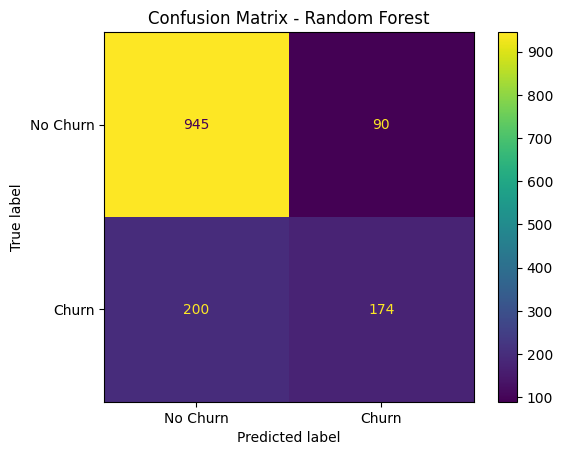

Confusion Matrix:
[[945  90]
 [200 174]]
      Metric  Decision Tree  Random Forest
0   Accuracy       0.798439       0.794180
1  Precision       0.663043       0.659091
2     Recall       0.489305       0.465241
3   F1-score       0.563077       0.545455


In [ ]:
#part 3
#task 5
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

# Calculate Random Forest metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy :  {rf_accuracy:.4f}")
print(f"Precision:  {rf_precision:.4f}")
print(f"Recall   :  {rf_recall:.4f}")
print(f"F1-score :  {rf_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Churn", "Churn"]
))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

print("Confusion Matrix:")
print(cm_rf)



#task 6
comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Decision Tree": [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt)
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

print(comparison_table)

Task 7

The Decision Tree performs slightly better than the Random Forest on all four metrics in this test-set comparison. The differences are relatively small: accuracy differs by about 0.42 percentage points, precision by 0.39 points, recall by 2.41 points, and F1-score by 1.76 points.

Because the dataset has an imbalanced target class, recall and F1-score are more important than accuracy. Recall is particularly important because it measures how many of the actual churners the model successfully identifies; therefore, missing churners is an important limitation in this problem. This is consistent with the reasoning from your Lab 3, where you identified recall and F1-score as more informative than accuracy for the churn problem.

In [ ]:
#part 4
#task 8
from sklearn.model_selection import cross_val_score

dt_cv = DecisionTreeClassifier(max_depth=6, random_state=42)

rf_cv = RandomForestClassifier(
    n_estimators=20,
    random_state=42
)

dt_scores = cross_val_score(
    dt_cv, X, y, cv=5, scoring="f1"
)

rf_scores = cross_val_score(
    rf_cv, X, y, cv=5, scoring="f1"
)

print("Decision Tree F1 scores:", dt_scores)
print("Decision Tree Mean F1:", dt_scores.mean())
print("Decision Tree Std:", dt_scores.std())

print("\nRandom Forest F1 scores:", rf_scores)
print("Random Forest Mean F1:", rf_scores.mean())
print("Random Forest Std:", rf_scores.std())

task 9:
The 5-fold cross-validation results support the Decision Tree as the stronger model, with a mean F1-score of 0.5736 compared with 0.5200 for the Random Forest. This gives more confidence in the conclusion from the single test split, where the Decision Tree also achieved a higher F1-score.

In [ ]:
#part 5
#task 10
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [20, 50],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1"
)

rf_grid.fit(X_train, y_train)

tuned_rf = rf_grid.best_estimator_


#task 11
print("Best Parameters:")
print(rf_grid.best_params_)

print("Best Cross-Validated F1-score:")
print(rf_grid.best_score_)

#task 12
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_tuned = tuned_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Tuned Random Forest")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1-score :", tuned_f1)

#part 6
#task 13
comparison = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_tuned)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_tuned)
    ]
}, index=[
    "Decision Tree",
    "Default Random Forest",
    "Tuned Random Forest"
])

print(comparison.round(4))


Task 14

The Decision Tree with max_depth=6 is the final model because it achieved the highest accuracy, recall, and F1-score on the held-out test set. The default Random Forest was slightly worse, while the tuned Random Forest performed substantially worse, especially in recall and F1-score. Therefore, the Decision Tree provides the best overall evidence-based choice for this dataset.

In [ ]:
#task 15
importances = pd.Series(
    dt_baseline.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances.head(10))

top5 = importances.head(5).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(top5.index, top5.values)
plt.xlabel("Importance")
plt.title("Top 5 Feature Importances - Final Decision Tree")
plt.tight_layout()
plt.show()

In [ ]:
#part 7
#task 16
test_customer_ids = df.loc[X_test.index, "customerID"]

submission = pd.DataFrame({
    "customerID": test_customer_ids,
    "Churn": pd.Series(y_pred_dt, index=X_test.index).map({
        1: "Yes",
        0: "No"
    })
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
print("Submission shape:", submission.shape)

#task 17
The Decision Tree with max_depth=6 was selected as the final model because it achieved the strongest overall test-set performance. It achieved 0.7984 accuracy, 0.6630 precision, 0.4893 recall, and 0.5631 F1-score, slightly outperforming the default Random Forest. The tuned Random Forest did not improve performance and produced a much lower recall and F1-score on the held-out test set. The main limitation of the final Decision Tree is its relatively low recall, meaning that many actual churners are still missed. The model also depends heavily on a small number of features, especially tenure and InternetService_Fiber optic.



#task 18
With more time, I would focus on handling the class imbalance directly using techniques such as class_weight='balanced' or SMOTE. I would also test other ensemble algorithms such as Gradient Boosting and XGBoost, perform broader but controlled hyperparameter tuning, and investigate better feature engineering. These approaches could improve recall and F1-score while reducing the number of actual churners that the model fails to identify.


